Viewer ready!


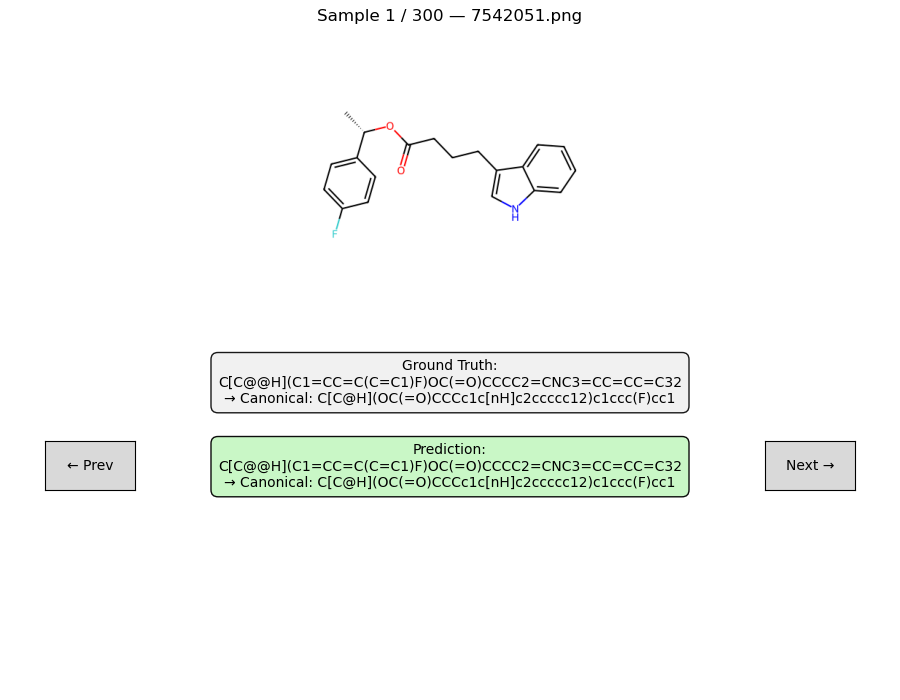

In [15]:
%matplotlib widget
import json
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from rdkit import Chem
import os

# Load evaluation results
CHECKPOINT = 25000
QWEN_MODEL = "2"
PARAM = "2B"
OUTPUT_JSON = f"Qwen{QWEN_MODEL}-{PARAM}_sft_eval_results_{CHECKPOINT}_Full.json"
with open(OUTPUT_JSON, "r") as f:
    results = json.load(f)

# Track index
index = 0

# Setup figure and layout
fig = plt.figure(figsize=(9, 7))
plt.subplots_adjust(left=0.05, right=0.95, top=0.93, bottom=0.1)

# Axes layout
image_ax = fig.add_axes([0.2, 0.55, 0.6, 0.4])
gt_ax = fig.add_axes([0.2, 0.42, 0.6, 0.07])
pred_ax = fig.add_axes([0.2, 0.30, 0.6, 0.07])
gt_ax.axis("off")
pred_ax.axis("off")

# Navigation buttons
prev_ax = fig.add_axes([0.05, 0.3, 0.1, 0.07])
next_ax = fig.add_axes([0.85, 0.3, 0.1, 0.07])
prev_button = Button(prev_ax, '← Prev')
next_button = Button(next_ax, 'Next →')

def canonical(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol)
    except:
        pass
    return None

def render(idx):
    sample = results[idx]

    # Image
    image_ax.clear()
    image_ax.imshow(plt.imread(sample["image_path"]))
    image_ax.axis("off")
    image_ax.set_title(
        f"Sample {idx+1} / {len(results)} — {os.path.basename(sample['image_path'])}",
        fontsize=12,
        pad=10
    )

    # Canonicalize
    gt_raw = sample["ground_truth"]
    pred_raw = sample["prediction"].replace("<answer>", "").replace("</answer>", "").strip()
    gt_canon = canonical(gt_raw)
    pred_canon = canonical(pred_raw)
    match = gt_canon == pred_canon if gt_canon and pred_canon else False

    # Ground Truth Box
    gt_ax.clear()
    gt_ax.axis("off")
    gt_text = f"Ground Truth:\n{gt_raw}"
    if gt_canon:
        gt_text += f"\n→ Canonical: {gt_canon}"
    else:
        gt_text += " [SMILES Parse Error]"
    gt_ax.text(
        0.5, 0.95, gt_text,
        fontsize=10, va="top", ha="center", wrap=True,
        bbox=dict(facecolor="#f0f0f0", edgecolor="black", boxstyle="round,pad=0.5", alpha=0.9)
    )

    # Prediction Box (with red/green depending on match)
    pred_ax.clear()
    pred_ax.axis("off")
    pred_text = f"Prediction:\n{pred_raw}"
    if pred_canon:
        pred_text += f"\n→ Canonical: {pred_canon}"
    else:
        pred_text += " [SMILES Parse Error]"

    pred_color = "#c6f7c3" if match else "#f9b1b1"  # Sharper green/red
    pred_ax.text(
        0.5, 0.95, pred_text,
        fontsize=10, va="top", ha="center", wrap=True,
        bbox=dict(facecolor=pred_color, edgecolor="black", boxstyle="round,pad=0.5", alpha=0.95)
    )

    fig.canvas.draw()

def next_event(event):
    global index
    index = (index + 1) % len(results)
    render(index)

def prev_event(event):
    global index
    index = (index - 1) % len(results)
    render(index)

# Hook up buttons
next_button.on_clicked(next_event)
prev_button.on_clicked(prev_event)

# Initial render
render(index)
print("Viewer ready!")
plt.show()


In [16]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

correct = 0
total = 0

for entry in results:
    total += 1
    if (canonical(entry['ground_truth'].replace("<answer>", "").replace("</answer>", "").strip()) == canonical(entry['prediction'].replace("<answer>", "").replace("</answer>", "").strip())):
        correct += 1

print(correct/total)
    

0.6733333333333333
